In [ ]:
# Hosted D2L setup: fetch the exact helper module used to build this notebook.
from pathlib import Path
from urllib.request import urlretrieve
from importlib.metadata import PackageNotFoundError, version
import importlib.util, os, subprocess, sys

required = ['numpy', 'pandas', 'matplotlib', 'requests', 'scipy', 'pillow', 'regex', 'jax', 'jaxlib', 'flax', 'optax', 'orbax-checkpoint', 'tensorflow', 'protobuf', 'ml-dtypes']
imports = {'pillow': 'PIL', 'orbax-checkpoint': 'orbax', 'protobuf': 'google.protobuf', 'ml-dtypes': 'ml_dtypes'}
pinned = {'jax': ('0.10.2', 'jax==0.10.2', 'jax[cuda12]==0.10.2', 'exact'), 'jaxlib': ('0.10.2', 'jaxlib==0.10.2', 'jaxlib==0.10.2', 'exact'), 'flax': ('0.12.7', 'flax==0.12.7', 'flax==0.12.7', 'exact'), 'optax': ('0.2.8', 'optax==0.2.8', 'optax==0.2.8', 'exact'), 'orbax-checkpoint': ('0.12.0', 'orbax-checkpoint==0.12.0', 'orbax-checkpoint==0.12.0', 'exact')}
fallbacks = {'tensorflow': 'tensorflow==2.21.0', 'protobuf': 'protobuf==7.34.1', 'ml-dtypes': 'ml-dtypes==0.5.4'}
device = os.environ.get("D2L_HOSTED_DEVICE", "auto").lower()
if device not in ("auto", "cpu", "gpu"):
    raise ValueError(f"Invalid D2L_HOSTED_DEVICE={device!r}")
if device == "auto":
    try:
        gpu = (Path("/dev/nvidia0").exists() or
               subprocess.run(["nvidia-smi", "-L"], capture_output=True,
                              timeout=5).returncode == 0)
    except (FileNotFoundError, subprocess.SubprocessError):
        gpu = False
else:
    gpu = device == "gpu"
if not gpu:
    os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
    os.environ.setdefault("JAX_PLATFORMS", "cpu")
tensorflow_version = None
if 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_version = version("tensorflow")
    except PackageNotFoundError:
        pass
# Colab's CPU image currently carries a CUDA-enabled TensorFlow wheel. Its
# first ordinary tensor operation probes CUDA and emits an error-level cuInit
# diagnostic. JAX notebooks also use TensorFlow for data loading, so overlay
# the matching CPU build in both CPU variants. Keep the provider's
# ``tensorflow`` distribution metadata: other preinstalled Colab packages
# depend on that distribution name, while both wheels expose the same module.
if not gpu and 'jax' in ("tensorflow", "jax"):
    try:
        tensorflow_cpu_version = version("tensorflow-cpu")
    except PackageNotFoundError:
        tensorflow_cpu_version = None
    if (tensorflow_version is not None and
            tensorflow_cpu_version != tensorflow_version):
        subprocess.check_call([
            sys.executable, "-m", "pip", "install", "-q", "--no-deps",
            f"tensorflow-cpu=={tensorflow_version}",
        ])
if "tf-keras" in fallbacks and tensorflow_version is not None:
    fallbacks["tf-keras"] = f"tf-keras=={tensorflow_version}"
missing = []
for package in required:
    if package in pinned:
        wanted, cpu_requirement, gpu_requirement, match = pinned[package]
        requirement = gpu_requirement if gpu else cpu_requirement
        try:
            installed = version(package)
        except PackageNotFoundError:
            installed = None
        actual = (installed.split("+", 1)[0]
                  if installed is not None and match == "public" else installed)
        if actual != wanted:
            missing.append(requirement)
    elif importlib.util.find_spec(imports.get(package, package)) is None:
        missing.append(fallbacks.get(package, package))
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])

mismatched = []
for package, (wanted, _, _, match) in pinned.items():
    try:
        installed = version(package)
    except PackageNotFoundError:
        installed = None
    actual = (installed.split("+", 1)[0]
              if installed is not None and match == "public" else installed)
    if actual != wanted:
        mismatched.append(f"{package}={installed!r} (expected {wanted})")
if mismatched:
    raise RuntimeError("Hosted runtime setup failed: " + ", ".join(mismatched))

root = Path(".d2l-hosted") / "8cd319b4f2187b6b29bb69603a96460fc325a975"
package = root / "d2l"
package.mkdir(parents=True, exist_ok=True)
base = "https://raw.githubusercontent.com/smolix/d2l-neu/8cd319b4f2187b6b29bb69603a96460fc325a975/d2l"
for name in ('__init__.py', 'jax.py'):
    target = package / name
    if not target.exists():
        urlretrieve(f"{base}/{name}", target)
if str(root.resolve()) not in sys.path:
    sys.path.insert(0, str(root.resolve()))
pythonpath = os.environ.get("PYTHONPATH", "").split(os.pathsep)
if str(root.resolve()) not in pythonpath:
    os.environ["PYTHONPATH"] = os.pathsep.join(
        [str(root.resolve()), *[entry for entry in pythonpath if entry]]
    )


# Selective State Space Models

The previous section ended on a confession. Everything we gained by
linearizing the recurrence, parallel training by scan, stability by
construction, provably good memory, came at the price of *time invariance*:
the S4D applies the same dynamics at every step, so what it remembers is
decided before it ever sees the input. Its convolution kernel weights the
past by *position*, never by *content*. The gated cells of
that section had the opposite profile: their forget gates read the
data as it streamed past and decided, token by token, what deserved space
in the state, but their nonlinear recurrence trained sequentially. This
section closes the loop. We make the step size, and with it the dynamics,
a *function of the input*, following @Gu.Dao.2023, and discover
that this one change re-derives the forget gate a third time while keeping
the parallel scan. The result, packaged into a residual block called
*Mamba*, brought selective recurrence into competitive language-model
scaling in 2023: S4 had already beaten every transformer of its day on
long-range classification benchmarks (that section), but
language modeling itself had remained attention's territory since the
transformer displaced the LSTM. Mamba also sharpens a question that the
rest of this chapter pursues: a selective state space model decides,
token by token, what to keep, and attention (that section)
decides, query by query, what to retrieve. How deep does that
resemblance run? Deeper than it has any right to, as the next section
shows.

*Prerequisites: the associative scan and the S4D layer of
that section (that section,
that section); the LSTM of that section; the
language-model harness and decoding utilities of
that section and that section.*

In [1]:
%matplotlib inline
from d2l import jax as d2l
from flax import nnx
import jax
from jax import numpy as jnp
import math
import numpy as np
import optax
import time

Everything in this section is built on the associative scan of
that section, which evaluates the affine recurrence
$\mathbf{h}_t = \mathbf{a}_t \odot \mathbf{h}_{t-1} + \mathbf{b}_t$ in
logarithmic depth.

That section saved the scan in the `d2l` library, so we simply pick it
back up.

In [2]:
associative_scan = d2l.associative_scan  # Saved in the previous section

## The Selectivity Problem

What does it mean, concretely, for a model to be content-blind? The LTI
convolution view the equation makes it precise: an S4D's output
is $y_t = \sum_k \bar{K}_k u_{t-k}$, and the kernel $\bar{\mathbf{K}}$ is
computed from the model's parameters alone. Whether the token ten steps
ago was the key fact of the paragraph or a comma, its influence on the
present is the same fixed number $\bar{K}_{10}$. A gated RNN would consult
its input before deciding; the LTI system cannot, because *deciding based
on the input* is exactly the time-variance it gave up.

### A Task That Defeats Time Invariance

To turn this from an observation into a measurement we borrow the
*selective copying* task that @Gu.Dao.2023 used to motivate
selectivity (the figure). Each input is a long stretch
of filler tokens in which a few *marked* symbols are scattered at random
positions; after the sequence, the model is prompted with query slots and
must reproduce the marked symbols, in order, ignoring everything else. A
solution has to do two content-dependent things: store a token *because
it is a symbol rather than filler*, and keep count of how many symbols it
has seen so far. Neither is expressible with position-based weights: the
same positions hold noise in one example and payload in the next.

![The selective copying task. A few marked symbols (color) are scattered among filler tokens (grey) at positions that change from example to example; prompted by query slots, the model must emit the symbols in order. Any fixed position-based kernel is defeated by design, since content decides what matters.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-modernrnn-selective-copy.svg)

This toy is not idle. Its language-scale counterpart is *associative
recall*: retrieving a value mentioned pages ago the next time its key
appears ("Mrs. Watchett ... later: Mrs. ___"). We have met the circuit
that does this: it is the induction head of
that section, which we built and watched form
during training, and @Arora.Eyuboglu.Timalsina.ea.2024 showed
that a small synthetic recall benchmark of this kind predicts most of
the language-modeling gap between attention and efficient recurrent
models. A sequence model that cannot selectively copy has no business
writing prose.

We generate the task synthetically: token $0$ is filler, token $1$ marks
the query slots, and the symbols occupy ids $2$ through $9$. The targets
are the eight-way symbol classes at the query positions.

In [3]:
def selective_copy(num_seqs, num_steps, num_marked, num_symbols, seed=42):
    """Sequences of filler (0) with num_marked symbols at random positions,
    followed by num_marked query slots (1); targets are the symbols."""
    rng = np.random.default_rng(seed)
    X = np.zeros((num_seqs, num_steps + num_marked), dtype=np.int64)
    X[:, num_steps:] = 1                          # Query slots
    Y = rng.integers(2, 2 + num_symbols, (num_seqs, num_marked))
    pos = np.argsort(rng.random((num_seqs, num_steps)), axis=1)
    pos = np.sort(pos[:, :num_marked], axis=1)    # Marked positions, in order
    np.put_along_axis(X, pos, Y, axis=1)
    return X, Y - 2                               # Classes 0..num_symbols-1

class SelectiveCopy(d2l.DataModule):
    def __init__(self, num_train=8192, num_val=1024, batch_size=128,
                 num_steps=256, num_marked=4, num_symbols=8):
        super().__init__()
        self.save_hyperparameters()
        X, Y = selective_copy(num_train + num_val, num_steps, num_marked,
                              num_symbols)
        self.X, self.Y = d2l.tensor(X), d2l.tensor(Y)

    def get_dataloader(self, train):
        idx = slice(0, self.num_train) if train else slice(self.num_train, None)
        return self.get_tensorloader([self.X, self.Y], train, idx)

copy_data = SelectiveCopy()

### An LTI Baseline and a Gated One

The prosecution calls two witnesses from earlier sections. The LTI
witness is the S4D stack exactly as we assembled it in
that section: since that section saved both the layer and its
residual block in the `d2l` library, two aliases suffice.

In [4]:
S4D, S4DBlock = d2l.S4D, d2l.S4DBlock

The gated witness is the LSTM of that section, via the concise
`d2l.LSTM` layer. Both plug into the same harness: embed the tokens, run
the encoder, and classify each of the final query positions. As in
that section we train with Adam, the default of the training
recipes in that section and the right tool for
parameters as differently scaled as log-decays and linear weights (the
reasoning of that section); we clip gradients to norm 1,
without which the LSTM destabilizes on these sequence lengths.

One implementation note: we embed tokens with a one-hot matrix product
rather than an embedding lookup. A lookup's gradient is a scatter-add,
and on this task every batch pushes 33,000 colliding updates into a
ten-row table, which XLA executes so slowly that it dominates the entire
training step; as a dense product, both passes are ordinary matrix
multiplications. Hold this thought: this section later argues that how a
computation maps onto hardware can matter as much as what it computes.

In [5]:
class CopyModel(d2l.Classifier):
    """Read a token sequence; predict the symbols at the query slots."""
    def __init__(self, encoder, num_hiddens, vocab_size=10, num_marked=4,
                 num_symbols=8, num_features=None, lr=3e-3, rngs=None):
        super().__init__()
        self.save_hyperparameters(ignore=['encoder', 'rngs'])
        rngs = nnx.Rngs(1) if rngs is None else rngs
        num_features = num_hiddens if num_features is None else num_features
        self.encoder = encoder
        # Embed by one-hot matmul: on a table this tiny (ten rows), the
        # scatter-add in an embedding lookup's gradient makes 33,000 colliding
        # updates to ten rows and serializes the whole training step on GPU;
        # as a dense product, forward and backward are ordinary matmuls
        self.emb = nnx.Linear(vocab_size, num_hiddens, use_bias=False,
                              rngs=rngs)
        self.head = nnx.Linear(num_features, num_symbols, rngs=rngs)

    def forward(self, X):
        E = self.emb(jax.nn.one_hot(X.T, self.vocab_size))
        Y = self.encoder(E)                             # (T, batch, hiddens)
        Y = Y[0] if isinstance(Y, tuple) else Y         # RNNs return a state
        return self.head(Y[-self.num_marked:]).swapaxes(0, 1)

    def configure_optimizers(self):
        return optax.adam(self.lr)

We give each model the same budget and record its validation accuracy
curve; `copy_curves` collects them, and a third contender will join in
that section. The two encoders are sized to roughly 30,000
parameters each, the same pairing that that section used for
sequential image classification, where the S4D *won*.

S4D: final validation accuracy 0.658


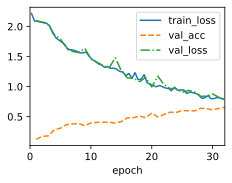

In [6]:
copy_curves = {}

def train_copy(name, model, data, epochs=32):
    trainer = d2l.Trainer(max_epochs=epochs, gradient_clip_val=1, num_gpus=1)
    trainer.fit(model, data)
    pts = model.board.data['val_acc']
    copy_curves[name] = ([p.x for p in pts], [float(p.y) for p in pts])
    print(f'{name}: final validation accuracy {copy_curves[name][1][-1]:.3f}')

s4d = CopyModel(nnx.Sequential(*[S4DBlock(48, 4) for _ in range(2)]),
                num_hiddens=48)
train_copy('S4D', s4d, copy_data)

LSTM: final validation accuracy 0.994


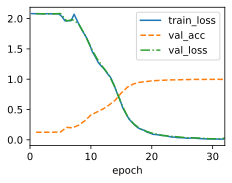

In [7]:
lstm = CopyModel(d2l.LSTM(num_inputs=48, num_hiddens=64), num_hiddens=48,
                 num_features=64)
train_copy('LSTM', lstm, copy_data)

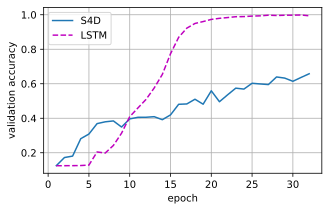

In [8]:
names = list(copy_curves)
d2l.plot([copy_curves[n][0] for n in names],
         [copy_curves[n][1] for n in names], 'epoch',
         'validation accuracy', legend=names, figsize=(5, 3))

The curves separate the way the content-blindness argument predicts. Both models
start at chance (one symbol in eight). The LSTM climbs toward a complete
solution, and in our runs ends the budget at or near perfect accuracy
(how fast depends on each framework's initialization defaults, the same
effect that section dissected): its input and forget gates are
functions of the data, so "store this, it is a symbol" is a computation
it can learn, given enough epochs. The S4D crawls. Its pointwise
nonlinear blocks can learn to suppress filler locally, which earns it
partial credit well above chance, but the time-invariant state cannot
cleanly align "the third symbol I saw" with "the third query slot" when
the spacing between symbols changes from example to example, and it ends
the same budget far from a solution. This is the first task in the book
where the *older* architecture is simply the right tool. That should
feel like a cliffhanger: the LSTM's advantage is precisely the
input-dependence that that section deleted for the sake of the
scan. Can we put it back without giving up parallel training?

## Selective State Space Models

### Making the Dynamics Look at the Data

Recall from that section where the S4D's dynamics come from: a
continuous system $(\mathbf{A}, \mathbf{B}, \mathbf{C})$ and a step size
$\Delta$, discretized by the zero-order hold into per-step coefficients.
Everything downstream of that box stays fixed; the *selective* state
space model of @Gu.Dao.2023 changes one design principle: the
SSM's parameters become functions of the input. The principle is
realized through three coupled projections. The step size, the input
matrix, and the read-out are no longer constants but functions of the
current input $\mathbf{u}_t \in \mathbb{R}^H$:

$$
\boldsymbol{\Delta}_t = \textrm{softplus}(\mathbf{u}_t \mathbf{W}_{\Delta} + \mathbf{b}_{\Delta}),
\qquad
\mathbf{B}_t = \mathbf{u}_t \mathbf{W}_{\textrm{B}},
\qquad
\mathbf{C}_t = \mathbf{u}_t \mathbf{W}_{\textrm{C}},
$$

with $\boldsymbol{\Delta}_t \in \mathbb{R}^H$ holding one step size per
channel (softplus keeps it positive) and
$\mathbf{B}_t, \mathbf{C}_t \in \mathbb{R}^N$ shared across channels. The
state matrix $\mathbf{A} = \textrm{diag}(a_1, \ldots, a_N)$ keeps its
fixed S4D parameterization; it sets the *menu* of decay rates, while
$\boldsymbol{\Delta}_t$ decides, per token, how far along that menu to
step. Discretizing exactly as before, channel $h$ of the layer now obeys

$$
\mathbf{x}_t = e^{\Delta_{t,h} \mathbf{a}} \odot \mathbf{x}_{t-1}
+ \Delta_{t,h}\, u_{t,h}\, \mathbf{B}_t,
\qquad
y_{t,h} = \mathbf{C}_t^\top \mathbf{x}_t + d_h\, u_{t,h},
$$

where $\mathbf{x}_t \in \mathbb{R}^N$ is that channel's state. (Mamba
simplifies the zero-order hold on the input path to the first-order rule
$\bar{\mathbf{B}}_t = \Delta_{t,h} \mathbf{B}_t$; the exponential on the
state path, which controls stability, is kept exact.)

Now watch what the boxed correspondence of that section does with
an input-dependent $\Delta$. There, a small $\Delta$ froze the state and
ignored the input; a large $\Delta$ flushed the state and admitted the
input. Make $\Delta$ a function of $\mathbf{u}_t$ and the model can
*choose per token*: filler should produce
$\Delta_t \approx 0$ (state glides through untouched, input contributes
nothing), while a marked symbol should produce a large $\Delta_t$ (reset
toward the new content). That is a forget gate and an input gate, fused
into one scalar, acting on a linear state. We have now derived the gate
three times, once by engineering (that section), once from
numerical integration (that section), and now from the demand
that a linear recurrence be able to ignore what does not matter.
$\mathbf{B}_t$ and $\mathbf{C}_t$ extend the same courtesy to *where*
input enters the state and *which* state coordinates are read out; an
exercise asks how much they add over selectivity in $\Delta$ alone.

### What Selectivity Costs, and What Survives

There is no free lunch: with time-varying coefficients the model is no
longer LTI, and the convolutional view of that section dies
on the spot. There is no fixed kernel $\bar{\mathbf{K}}$ to materialize
and no FFT shortcut; of the three views in the figure, only
the recurrence survives. This is why we built the scan rather than the
FFT in that section. The recurrence
the equation is still an *affine* map of the state, just
with per-step coefficients, and the associative combine
the equation never assumed those coefficients were constant.
The same `associative_scan`, called with tensors whose leading axis now
varies per step, evaluates the selective recurrence in the same
logarithmic depth. Seeing is believing, one more time: a sequential loop
with time-varying decays against the scan.

In [9]:
num_steps, num_states = 100, 4
key1, key2 = jax.random.split(d2l.get_key())
a_t = jax.random.uniform(key1, (num_steps, num_states))  # Decays in (0, 1)
b_t = jax.random.normal(key2, (num_steps, num_states))   # Per-step inputs
h, ys = jnp.zeros(num_states), []
for t in range(num_steps):
    h = a_t[t] * h + b_t[t]
    ys.append(h)
err = jnp.abs(associative_scan(a_t, b_t) - jnp.stack(ys)).max()
print(f'time-varying scan vs loop: {float(err):.2e}')

time-varying scan vs loop: 4.77e-07


The layer below packages the equation and
the equation. Next to the `S4D` class it differs in three
places: $\Delta$, $\mathbf{B}$, $\mathbf{C}$ are computed from `u` by
small linear heads rather than stored as parameters; the $\Delta$ head is
factored through rank $H/16$ (Mamba's `dt_rank`), which keeps its
parameter count negligible; and its bias is initialized so that
$\textrm{softplus}$ of it reproduces the log-uniform step sizes of
that section. Only the initial decay timescales carry over from
the S4D, though: $\mathbf{B}_t$ and $\mathbf{C}_t$ come out of randomly
initialized heads, so the layer is input-dependent from its first
forward pass rather than starting as an LTI system. The scan call is
unchanged, except that the decay tensor now genuinely spans
`(num_steps, batch, H, N)` instead of broadcasting one value.

In [10]:
class SelectiveSSM(nnx.Module):
    """A diagonal SSM whose step size, input matrix, and read-out are
    functions of the input (Gu & Dao, 2023)."""
    def __init__(self, num_hiddens, num_states=4, dt_min=0.001, dt_max=0.1,
                 rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        H, N, R = num_hiddens, num_states, max(2, num_hiddens // 16)
        self.log_a = nnx.Param(jnp.tile(jnp.log(jnp.arange(1., N + 1)),
                                        (H, 1)))
        self.W_dt = nnx.Sequential(
            nnx.Linear(H, R, rngs=rngs),
            nnx.Linear(R, H, use_bias=False, rngs=rngs))
        dt = jnp.exp(rngs.params.uniform((H,)) * math.log(dt_max / dt_min)
                     + math.log(dt_min))
        self.b_dt = nnx.Param(dt + jnp.log(-jnp.expm1(-dt)))
        self.W_B = nnx.Linear(H, N, use_bias=False, rngs=rngs)
        self.W_C = nnx.Linear(H, N, use_bias=False, rngs=rngs)
        self.D = nnx.Param(jnp.ones(H))

    def __call__(self, u):                   # (num_steps, batch, num_hiddens)
        a = -jnp.exp(self.log_a[...])                 # (H, N), Re(a) < 0
        dt = jax.nn.softplus(self.W_dt(u) + self.b_dt)    # (T, batch, H)
        B, C = self.W_B(u), self.W_C(u)               # (T, batch, N)
        a_bar = jnp.exp(dt[..., None] * a)            # (T, batch, H, N)
        b_bar = (dt * u)[..., None] * B[..., None, :]
        x = associative_scan(a_bar, b_bar)
        return (x * C[..., None, :]).sum(-1) + self.D * u

One prose remark on engineering, because it explains why this
architecture arrived in 2023 rather than 2020. Our implementation
materializes the `(num_steps, batch, H, N)` coefficient tensors in GPU
memory, which is fine at textbook scale and ruinous at model scale: the
computation is trivially cheap per element, so its speed is set entirely
by memory traffic. The Mamba authors' kernel never materializes those
tensors. It fuses discretization, scan, and read-out into a single pass
that keeps intermediates in fast on-chip memory, and during
backpropagation *recomputes* them from the small inputs instead of
storing them, trading a little arithmetic for a lot of bandwidth, the
same store-versus-recompute trade we met in that section. None of
this changes what is computed. It changed whether the architecture was
*worth* computing, and it is half the reason the paper's title contains
the word "hardware-aware".

## The Mamba Block

The selective SSM mixes information across time. Like the S4D it needs a
scaffold around it that mixes channels and supplies nonlinearity, and
Mamba's block, the figure, differs instructively from the
S4D block of the figure. Instead of alternating a sequence
layer with a separate gated MLP, Mamba fuses the two: one linear
projection widens the input from $d$ to an expanded $2d$ and forks it
into two branches. The main branch is convolved with a short *causal*
convolution (width 4; a cheap way to let each token see a few immediate
predecessors before deciding its dynamics), passed through a SiLU
activation, and fed to the selective SSM. The other branch, after its own
SiLU, multiplies the SSM's output elementwise, one final gate, echoing
that section yet again, so that even the read-out is
content-controlled. A linear projection maps the expanded width back to
$d$, and the whole thing sits inside the usual pre-norm residual.

The comparison with the transformer block of
that section is worth making precisely. That block
divides its labor: an attention sub-block mixes information across
positions, then an MLP sub-block (with its own residual and
normalization) mixes across channels, and the two alternate through the
stack. Mamba fuses the same two jobs into one unit: the selective SSM is
the sequence mixer, the expanded gated projections around it are the
channel mixer, and a Mamba language model is this single homogeneous
block stacked $L$ times where a transformer alternates two. The deeper
question, whether the *mixers themselves* are secretly the same
operation, is exactly where this chapter is headed.

![The Mamba block. An input projection widens $d$ to $2d$ and forks: the main branch runs a short causal convolution, a SiLU, and the selective SSM, whose step size, input and read-out matrices are functions of its input; the gate branch applies a SiLU and multiplies the SSM output elementwise. An output projection returns to width $d$ inside a pre-norm residual.](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-modernrnn-mamba-block.svg)

With `SelectiveSSM` in hand the block is a dozen lines, and a language
model is the block stacked plus the embedding and head that
`d2l.RNNLM` of that section already provides. The stack
exposes the `(inputs, state)` calling convention of our recurrent cells,
so it drops into the same scaffold as every other model in this chapter;
like the S4D, it trains with Adam. All three classes go into the `d2l`
library: the chapter's closing section builds its hybrid stacks out of
them.

In [11]:
class MambaBlock(nnx.Module):
    """Conv + SiLU + selective SSM, gated, inside a pre-norm residual."""
    def __init__(self, num_hiddens, num_states=4, expand=2, conv_width=4,
                 dropout=0, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        d = expand * num_hiddens
        self.ln = nnx.LayerNorm(num_hiddens, rngs=rngs)
        self.W_in = nnx.Linear(num_hiddens, 2 * d, rngs=rngs)
        self.conv = nnx.Conv(d, d, kernel_size=(conv_width,),
                             feature_group_count=d, padding='CAUSAL',
                             rngs=rngs)
        self.ssm = SelectiveSSM(d, num_states, rngs=rngs)
        self.W_out = nnx.Linear(d, num_hiddens, rngs=rngs)
        self.drop = nnx.Dropout(dropout, rngs=rngs)

    def __call__(self, X):                   # (num_steps, batch, num_hiddens)
        u, gate = jnp.split(self.W_in(self.ln(X)), 2, axis=-1)
        u = jnp.swapaxes(self.conv(jnp.swapaxes(u, 0, 1)), 0, 1)
        y = self.ssm(jax.nn.silu(u))
        return X + self.drop(self.W_out(y * jax.nn.silu(gate)))

class Mamba(nnx.Module):
    """A stack of Mamba blocks with the recurrent-cell interface."""
    def __init__(self, num_inputs, num_blocks=2, num_states=4, dropout=0,
                 rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        self.num_inputs = self.num_hiddens = num_inputs
        self.blocks = nnx.Sequential(*[
            MambaBlock(num_inputs, num_states, dropout=dropout, rngs=rngs)
            for _ in range(num_blocks)])
        self.ln = nnx.LayerNorm(num_inputs, rngs=rngs)

    def __call__(self, X, state=None):
        return self.ln(self.blocks(X)), None

What we have just assembled is a *pedagogical Mamba-style block*, not a
reproduction of the paper's implementation.
the table records what carries over and what
was cut down, so that the measurements below are read at the right
resolution.

<!-- tbl-caption:What our implementation keeps from Mamba and what it simplifies. -->

| kept from Mamba | simplified here | effect |
|:--|:--|:--|
| the selective mechanism the equationthe equation: $\Delta, \mathbf{B}, \mathbf{C}$ from the input, exact exponential state decay, S4D-style $\mathbf{A}$ and $\Delta$-bias initialization, the conv--SiLU--gate block layout | nothing | the mechanism the experiments probe is the paper's |
| the scan's mathematics: the same affine combine, the same logarithmic depth | the fused kernel becomes a generic `associative_scan` that materializes the $(T, \textrm{batch}, H, N)$ coefficient tensors | identical outputs; memory traffic sets the wall clock, the slow `s/epoch` column below |
| the block interface: width expansion, gating, pre-norm residual | textbook scale ($N = 4$ states, two blocks), LayerNorm in place of RMSNorm, added dropout | small enough to train in a notebook; the results are illustrations at this scale, not scaling claims |

### The Three Answers, Measured on One Task

This chapter proposed three answers to its opening question of what a
hidden state should remember: *gate it* (the LSTM), *linearize it* (the
minGRU and the SSMs), *select it* (Mamba). Time to put all three on one
scoreboard. The task is the language-modeling recipe used throughout,
*The Time Machine* under the 1,024-token BPE tokenizer of
that section, 50,000 windows of 32 tokens, ten epochs,
gradients clipped to norm 1. Alongside perplexity we report bits per byte
(all three models share one tokenizer, but bpb keeps the scoreboard
comparable with the character-level models of that section), parameter
counts, and wall clock per epoch. The tokens-to-bytes conversion decodes
the full validation target stream, so bpb is normalized over exactly the
tokens that the validation perplexity averages.

In [12]:
data = d2l.TimeMachine(batch_size=1024, num_steps=32,
                       num_train=50000, num_val=5000)
ids = d2l.numpy(data.Y[data.num_train:data.num_train + data.num_val]
                ).reshape(-1).tolist()               # Full val target stream
bytes_per_token = len(data.tokenizer.decode(ids).encode('utf-8')) / len(ids)

In [13]:
results = {}

def val_ppl(model):
    model = nnx.view(model, deterministic=True, use_running_average=True,
                     raise_if_not_found=False)  # Dropout off for evaluation
    total_loss = num_tokens = 0
    for X_val, y_val in data.val_dataloader():
        losses = model.loss(model(X_val), y_val, averaged=False)
        total_loss += float(losses.sum())
        num_tokens += losses.size
    return math.exp(total_loss / num_tokens)

def benchmark(name, model, epochs=10):
    trainer = d2l.Trainer(max_epochs=epochs, gradient_clip_val=1, num_gpus=1)
    model.board.yscale = 'log'
    start = time.time()
    trainer.fit(model, data)
    secs = (time.time() - start) / epochs
    params = sum(p.size for p in
                 jax.tree.leaves(nnx.state(model, nnx.Param)))
    results[name] = (val_ppl(model), math.log2(val_ppl(model))
                     / bytes_per_token, params, secs)

The first answer, the LSTM of that section, and the second, the
minGRU of that section (restated below), train with the exact
recipes of their home sections.

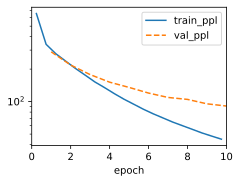

In [14]:
lstm_lm = d2l.RNNLM(d2l.LSTM(num_inputs=64, num_hiddens=128),
                    vocab_size=len(data.vocab), lr=4)
benchmark('LSTM', lstm_lm)

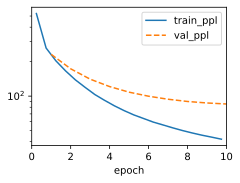

In [15]:
class MinGRU(nnx.Module):
    """The minimal GRU of the previous section."""
    def __init__(self, num_inputs, num_hiddens, rngs=None):
        rngs = nnx.Rngs(0) if rngs is None else rngs
        self.num_inputs, self.num_hiddens = num_inputs, num_hiddens
        self.W_xz = nnx.Linear(num_inputs, num_hiddens, rngs=rngs)
        self.W_xh = nnx.Linear(num_inputs, num_hiddens, rngs=rngs)

    def __call__(self, inputs, H=None):
        Z = jax.nn.sigmoid(self.W_xz(inputs))    # (num_steps, batch, hiddens)
        H_tilde = jnp.tanh(self.W_xh(inputs))
        a, b = 1 - Z, Z * H_tilde
        if H is not None:  # Fold the carried-in state into the first step
            b = jnp.concatenate([b[:1] + a[:1] * H, b[1:]])
        outputs = associative_scan(a, b)
        return outputs, outputs[-1]

mingru_lm = d2l.RNNLM(MinGRU(num_inputs=64, num_hiddens=128),
                      vocab_size=len(data.vocab), lr=4)
benchmark('minGRU', mingru_lm)

The third answer stacks two Mamba blocks at model width 128. Since
`d2l.RNNLM` supplies embedding and head around any module with the
`(inputs, state)` interface, only the optimizer needs overriding. One
adjustment is needed, and it is a compliment in disguise: trained like
the baselines, this model *overfits*. Its validation perplexity bottoms
out within a few epochs and then climbs while training perplexity keeps
falling toward single digits, which no gated model in this chapter comes
close to doing; a selective state is, among other things, an excellent
memorization device, and our corpus is one short novel. So Mamba, alone
in this chapter, gets the standard medicine of that section,
dropout on each block's residual branch, plus a gentler learning rate.

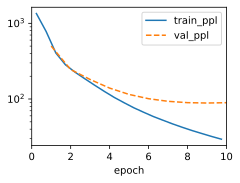

In [16]:
class MambaLM(d2l.RNNLM):
    def configure_optimizers(self):
        return optax.adam(self.lr)

mamba_lm = MambaLM(Mamba(num_inputs=128, dropout=0.3),
                   vocab_size=len(data.vocab), lr=3e-4)
benchmark('Mamba', mamba_lm)

In [17]:
print(f'{"model":>7} {"val ppl":>8} {"bpb":>6} {"params":>9} {"s/epoch":>8}')
for name, (ppl, bpb, params, secs) in results.items():
    print(f'{name:>7} {ppl:>8.1f} {bpb:>6.2f} {params:>9,} {secs:>8.1f}')

  model  val ppl    bpb    params  s/epoch
   LSTM     90.7   2.34   297,027      1.5
 minGRU     85.3   2.31   214,851      1.0
  Mamba     88.9   2.33   488,739      2.5


Numbers first, then caveats. In every framework we run, Mamba lands
below the LSTM, by a few points of perplexity in some reruns and by
tens in others, at a parameter count larger than the LSTM's (most of the extra
sits in the block's expanded projections) and a slower epoch, our scan
being the teaching-grade version of the fused kernel discussed above. In
most runs it posts the best number of the chapter outright, though in
some the minGRU, at fewer than half the parameters, stays within a few
points or even edges it out: at this scale, framework initialization
defaults and optimizer choices move the scoreboard by amounts comparable
to the architectural gap. The caveats cut both ways: Mamba trains
with Adam and dropout while the gated baselines keep their sections'
plain SGD recipe, and at this corpus size a stronger model mostly buys
sharper memorization of Wells's prose. This scoreboard says the selective
architecture *can* be trained to better held-out prediction at comparable
scale, not that it dominates pound for pound; at research scale the
corresponding claim, matching transformers at small model sizes, is the
Mamba paper's central result.

### Stepping the Selective Model

Before we sample from these models, a debt falls due.
that section stepped the LTI model one token at a time;
does the trick survive selectivity? It does, and for a reason worth
noticing: the equation computes $\boldsymbol{\Delta}_t,
\mathbf{B}_t, \mathbf{C}_t$ from the *current* input alone, so a single
token is all the step needs to build its own coefficients before
applying the same recurrence as before. The one genuinely new piece of
state sits outside the SSM: the block's causal convolution looks at the
last `conv_width` inputs, so the step must carry a rolling buffer of
the four most recent values alongside the $(H, N)$ state. This pair,
conv buffer plus SSM state, is exactly what production Mamba
implementations cache during decoding; it is the entire inference-time
memory of a layer, a few kilobytes where a transformer layer's KV cache
grows by the equation with every token generated
(that section).

In [18]:
@d2l.add_to_class(SelectiveSSM)
def step(self, u, x=None):
    """Advance one token: u is (batch, H); x is the (batch, H, N) state."""
    a = -jnp.exp(self.log_a[...])
    dt = jax.nn.softplus(self.W_dt(u) + self.b_dt)    # (batch, H)
    B, C = self.W_B(u), self.W_C(u)                   # (batch, N)
    a_bar = jnp.exp(dt[..., None] * a)                # (batch, H, N)
    b_bar = (dt * u)[..., None] * B[..., None, :]
    x = b_bar if x is None else a_bar * x + b_bar
    return (x * C[..., None, :]).sum(-1) + self.D * u, x

@d2l.add_to_class(MambaBlock)
def step(self, X, state=None):
    """Advance one token, carrying (conv buffer, SSM state)."""
    u, gate = jnp.split(self.W_in(self.ln(X)), 2, axis=-1)
    if state is None:
        state = (jnp.zeros((u.shape[0], self.conv.kernel_size[0],
                            u.shape[-1])), None)
    buf, x = state
    buf = jnp.concatenate([buf[:, 1:], u[:, None]], 1)    # Roll the window
    u = (buf * self.conv.kernel[:, 0]).sum(1) + self.conv.bias
    y, x = self.ssm.step(jax.nn.silu(u), x)
    return X + self.drop(self.W_out(y * jax.nn.silu(gate))), (buf, x)

@d2l.add_to_class(Mamba)
def step(self, X, state=None):
    """Advance the stack one token: X is (batch, d); one state per block."""
    state = ([None] * len(self.blocks.layers) if state is None
             else list(state))
    for i, blk in enumerate(self.blocks.layers):
        X, state[i] = blk.step(X, state[i])
    return self.ln(X), state

As in that section, the check that matters runs on the
*trained* model: we push a batch of validation windows through the
capstone language model with the scan, then again token by token with
`step`, and assert that the logits agree, relative to their scale, far
more tightly than float32 rounding is obliged to deliver. (Dropout must
be off, or the two passes would disagree by design.)

In [19]:
eval_lm = nnx.view(mamba_lm, deterministic=True, use_running_average=True,
                   raise_if_not_found=False)     # Dropout off
X = jnp.asarray(data.X[data.num_train:data.num_train + 8])
with jax.default_matmul_precision('float32'):    # TF32 off, as before
    logits_scan = eval_lm(X)                     # (batch, T, vocab)
    state, cols = None, []
    for t in range(X.shape[1]):                  # One token at a time
        emb = eval_lm.emb(X[:, t][None])         # (1, batch, d)
        y, state = eval_lm.rnn.step(emb[0], state)
        cols.append(eval_lm.linear(y))
    logits_step = jnp.stack(cols, 1)
err = float(jnp.abs(logits_step - logits_scan).max())
scale = float(jnp.abs(logits_scan).max())
print(f'stepped vs scanned logits: deviation {err:.2e}, '
      f'relative {err / scale:.2e}')
assert err < 1e-3 * scale

stepped vs scanned logits: deviation 4.77e-06, relative 4.38e-07


Every language model in this book must also pass the smell test of
that section: generate something. We sample each model with
the same prefix, temperature, and min-$p$ filter, using the
`d2l.generate` helper built there. For the gated baselines we keep that
section's harness, which re-runs the growing prefix at every token; for
Mamba we now do it properly. `d2l.generate` hands our callback the full
token list each call, so the closure below keeps `(state, seen)` and
feeds only the *unseen* suffix through `step`: the first call plays the
prompt into the state and every later call advances one token, the same
prefill/decode split that that section built for the
transformer, except that here the "cache" never grows. Generation cost
falls from quadratic in the output length to linear.

In [20]:
def step_fn(model):
    model = nnx.view(model, deterministic=True, use_running_average=True,
                     raise_if_not_found=False)  # Dropout off for sampling
    def step(ids):  # Token ids in, numpy logits for the next token out
        return d2l.numpy(model(d2l.tensor([ids])))[0, -1]
    return step

def stepped_fn(model):
    model = nnx.view(model, deterministic=True, use_running_average=True,
                     raise_if_not_found=False)  # Dropout off for sampling
    state, seen = None, 0
    def step(ids):  # Consume only the tokens the state has not absorbed
        nonlocal state, seen
        for i in ids[seen:]:
            emb = model.emb(jnp.array([[i]]))
            y, state = model.rnn.step(emb[0], state)
        seen = len(ids)
        return d2l.numpy(model.linear(y))[0]
    return step

prefix = data.tokenizer.encode('the time traveller')
for name, model, fn in [('LSTM', lstm_lm, step_fn),
                        ('minGRU', mingru_lm, step_fn),
                        ('Mamba', mamba_lm, stepped_fn)]:
    out = d2l.generate(fn(model), prefix, 25, strategy='sample',
                       temperature=1.0, min_p=0.1,
                       rng=np.random.default_rng(0))
    print(f'{name:>7}: {data.tokenizer.decode(out)!r}')

   LSTM: 'the time traveller. I had a clighted, and soft,\nand resence of the world, and it was in'


 minGRU: "the time travellering, and the ending of the haility of the Time Machine, and then the Psychologist. I'\nf"


  Mamba: 'the time traveller, I was slored and fruit of the delicate entands of the sphinx.'


### Selective Copying, Revisited

The scoreboard above is the everyday test; the section opened with the
diagnostic one. We now run the Mamba stack on the selective copying task
that the S4D could not solve, at the same parameter budget as before, and
replot all three curves together.

Mamba: final validation accuracy 0.998


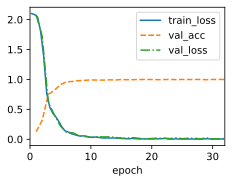

In [21]:
mamba_copy = CopyModel(
    nnx.Sequential(*[MambaBlock(48, 4) for _ in range(2)]), num_hiddens=48)
train_copy('Mamba', mamba_copy, copy_data)

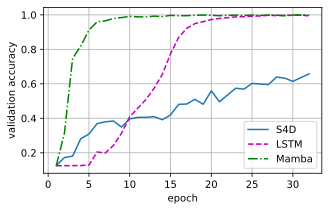

In [22]:
names = list(copy_curves)
d2l.plot([copy_curves[n][0] for n in names],
         [copy_curves[n][1] for n in names], 'epoch',
         'validation accuracy', legend=names, figsize=(5, 3))

Mamba solves the task, and faster than the LSTM did. The mechanism we
*designed* is that filler should collapse the learned $\Delta_t$ toward
zero, so the state carries the stored symbols forward untouched, while a
marked symbol should open $\Delta_t$ and write. Whether training found
that mechanism is a measurable question, not one to assert: $\Delta_t$
is an inference-time quantity, one forward pass away. The cell below
pushes held-out sequences through the trained model and collects each
block's step sizes by token role.

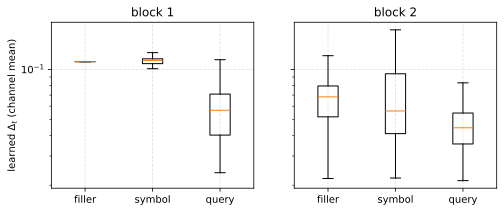

In [23]:
eval_copy = nnx.view(mamba_copy, deterministic=True,
                     use_running_average=True, raise_if_not_found=False)
X = jnp.asarray(copy_data.X[copy_data.num_train:copy_data.num_train + 512])
h, dts = eval_copy.emb(jax.nn.one_hot(X.T, eval_copy.vocab_size)), []
for blk in eval_copy.encoder.layers:
    u, _ = jnp.split(blk.W_in(blk.ln(h)), 2, axis=-1)
    u = jnp.swapaxes(blk.conv(jnp.swapaxes(u, 0, 1)), 0, 1)
    dt = jax.nn.softplus(blk.ssm.W_dt(jax.nn.silu(u)) + blk.ssm.b_dt)
    dts.append(d2l.numpy(dt.mean(-1)))      # Mean step size, (T, batch)
    h = blk(h)                              # On to the next block
roles = d2l.numpy(X.T)
masks = [roles == 0, roles >= 2, roles == 1]
fig, axes = d2l.plt.subplots(1, len(dts), figsize=(8, 3), sharey=True)
for i, (ax, dt) in enumerate(zip(axes, dts)):
    ax.boxplot([dt[m] for m in masks], showfliers=False)
    ax.set_xticks([1, 2, 3], ['filler', 'symbol', 'query'])
    ax.set_yscale('log')
    ax.set_title(f'block {i + 1}')
    ax.grid(linestyle='--', alpha=0.4)
axes[0].set_ylabel(r'learned $\Delta_t$ (channel mean)');

The trained step sizes separate by role: on filler tokens $\Delta_t$
sits low, on the marked symbols it opens, and the query slots read out
with their own regime. That is the narrated gate, measured rather than
asserted, on the model that solved the task. The architectural circle
closes here. The content-dependent gating that that section
deleted to linearize the recurrence has been restored, not by putting
the state back inside a nonlinearity, but by letting the input choose
the coefficients of a linear map, and the scan never noticed the
difference.

We have now built selectivity from the state-space side: start from
continuous dynamics, discretize, and let the input set the step size.
The next section (that section) starts over from the
attention side, with the linear-attention recurrence of
that section, and arrives at the same recurrence.

## Summary

![One question, three answers so far: gate the state (LSTM), linearize the state path and scan (minGRU, S4D), make the linear dynamics select by content (Mamba).](https://raw.githubusercontent.com/smolix/d2l-neu/notebooks/img/mdl-modernrnn-three-answers.svg)

This chapter opened by asking what a hidden state should remember, and
has now given three answers of increasing refinement
(the figure). *Gate it*: multiplicative gates let the
data control writing, keeping, and exposing memory, and made recurrent
networks trainable over long ranges. *Linearize it*: removing the
nonlinearity from the state path turned the recurrence into an
associative scan, restoring parallel training, and the state space view
added principled step-size gates, stability by construction, and
provably good memory. *Select it*: making the step size and projections
functions of the input restored the content-awareness that
linearization lost, at the same asymptotic scan depth though not the
same wall clock (our teaching-grade scan materializes its coefficient
tensors and pays several times the gated baselines' time per epoch).
The resulting Mamba block solved our selective-copy task, posted the
best perplexity of the chapter in our PyTorch run (the minGRU edged it
out in the JAX run), and, stepped one token at a time, generated text
at constant cost per token from a state of a few kilobytes. What no
update rule can change is that a fixed-size state at finite precision
holds a fixed number of bits; what that limit costs, and how production
systems buy it back with a few layers of attention, is where this
chapter ends. First, though, comes a reckoning: the selective
recurrence we built from ODEs and the attention we built in
that section are about to turn out to be the same
computation (that section).

What this section's experiments do and do not show: the selective-copy
runs are a *diagnostic*, built so that content-independent dynamics
fail it. They show our S4D stack stalling and Mamba solving the same
instance, with the measured $\Delta_t$ separation as the mechanism;
they do not show that no time-invariant model of any size could
memorize a bounded version of the task. The capstone scoreboard is an
*illustration*: one small corpus, one recipe per model, single seeded
runs. It shows that the selective architecture can be trained to the
best held-out perplexity at this scale, as it was in our PyTorch run,
not a pound-for-pound ranking. The step-versus-scan agreement is an
*identity check* on the trained network and holds to float tolerance in
both frameworks.

## Exercises

1. [extended] *Selective in $\Delta$ only.* Modify `SelectiveSSM` so that only
   $\boldsymbol{\Delta}_t$ depends on the input, with
   $\mathbf{B} = \mathbf{1}$ fixed and $\mathbf{C}$ a plain parameter as
   in `S4D`, and rerun the selective copying experiment. Then try the
   converse (input-dependent $\mathbf{B}_t, \mathbf{C}_t$ with a fixed
   learned $\Delta$). Which ingredient carries the task, and why does
   that agree with the gate interpretation of that section?
1. [extended] *Finding the capacity cliff.* Fix the Mamba copy model and grow the
   task: sweep the number of marked symbols (say 4, 8, 16, 32) at
   `num_states=4`, then repeat with `num_states=16`. Plot final accuracy
   against the number of symbols for both state sizes. Where does each
   model break, and how does the break point move with state size? To
   hold $k$ symbols from an alphabet of $V$, the state must carry
   $k \log_2 V$ bits: does the cliff you measured sit where this
   accounting predicts?
1. [extended] *Ablating the block.* The Mamba block multiplies the SSM output by a
   SiLU gate branch. Remove the gate (pass the SSM output straight to
   `W_out`), and separately replace both SiLU activations by ReLU or by
   the identity. Retrain the capstone language model for each variant.
   Which change hurts most, and does the gate matter more for perplexity
   or for the selective-copy task?
1. [extended] *Bytes instead of BPE.* Rerun the capstone comparison at the byte
   level by constructing the dataset with
   `d2l.TimeMachine(..., tokenization='char')` and doubling `num_steps`
   so each window spans comparable text. Compare LSTM and Mamba by bits
   per byte, not perplexity. Does Mamba's advantage grow or shrink, and
   why might a selective state suit long, low-information-density token
   streams?
1. [short-code] *Chunked prefill.* Our `stepped_fn` plays the prompt into the state
   one token at a time, but `Mamba.forward` computes the same states
   with the parallel scan and then throws them away (it returns `None`).
   Modify `forward` so it also returns the final `(conv buffer, SSM
   state)` pair of every block, prefill with one scan over the prompt,
   hand the result to `step` for decoding, and verify that the generated
   logits match pure stepping. This scan-prefill-then-step schedule is
   how production Mamba serving actually processes prompts, and the same
   division of labor as prefill versus decode in that section.

[Discussions](https://d2l.discourse.group/)